DATASET LOADED SUCCESSFULLY

FIRST 5 ROWS
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1 

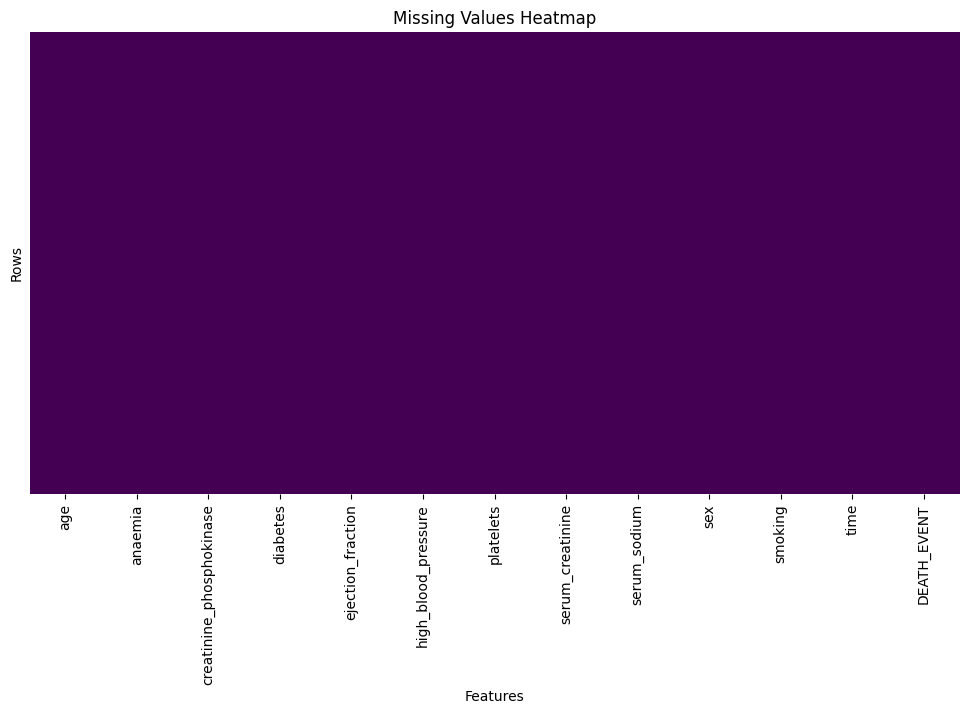


DUPLICATE ROWS
Number of duplicate rows: 0
No duplicate rows found.


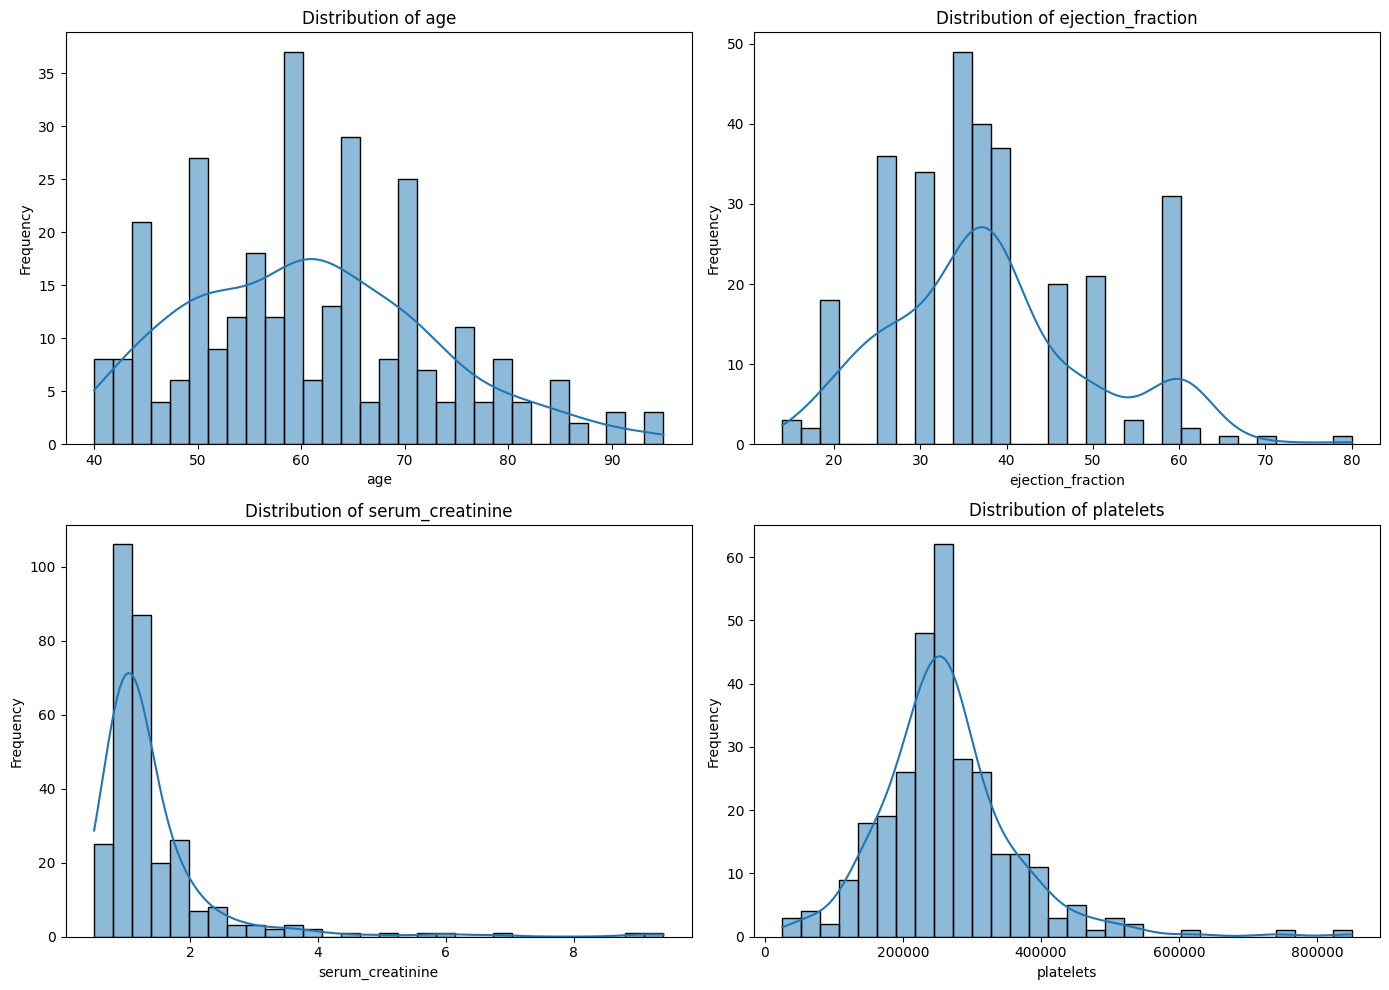

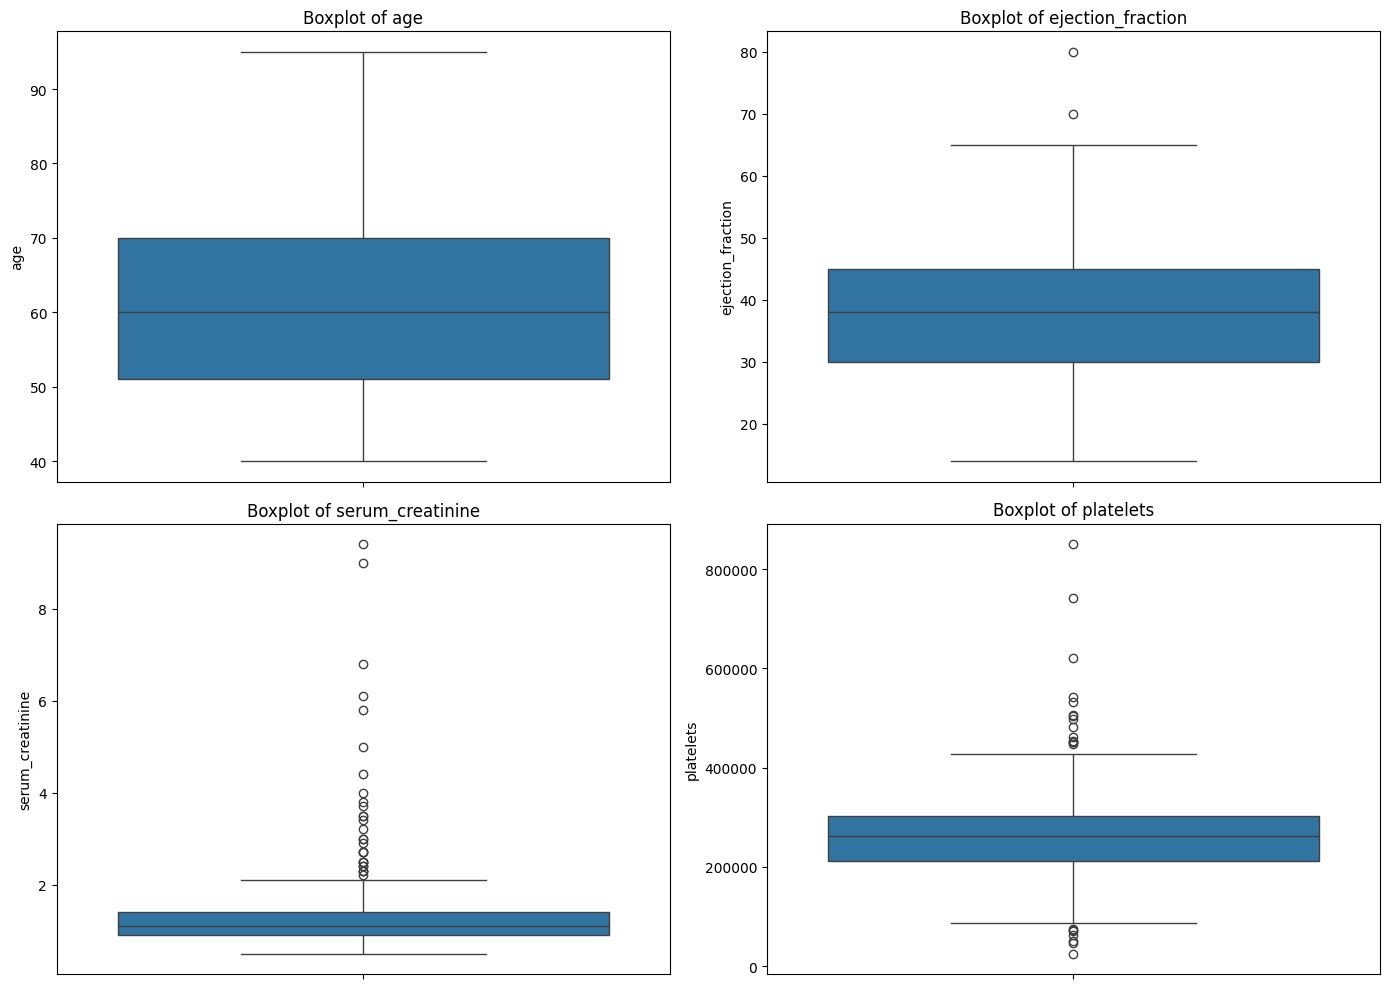


CHECKING INVALID VALUES
Negative age values: 0
Negative ejection fraction values: 0
Negative serum creatinine values: 0
Negative platelets values: 0

OUTLIER REMOVAL
Rows before outlier removal: 299
Rows after outlier removal: 224
Rows removed: 75

AGE GROUP DISTRIBUTION
age_group
>60      125
40-60     99
<40        0
Name: count, dtype: int64

RISK SCORE
   ejection_fraction  serum_creatinine  risk_score
0               20.0               1.9    0.101961
2               20.0               1.3    0.054902
3               20.0               1.9    0.101961
5               40.0               2.1    0.509804
6               15.0               1.2    0.007843

DATA AFTER ENCODING
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0               20.0   
2  65.0        0                       146         0               20.0   
3  50.0        1                       111         0               20.0   
5  90.0      

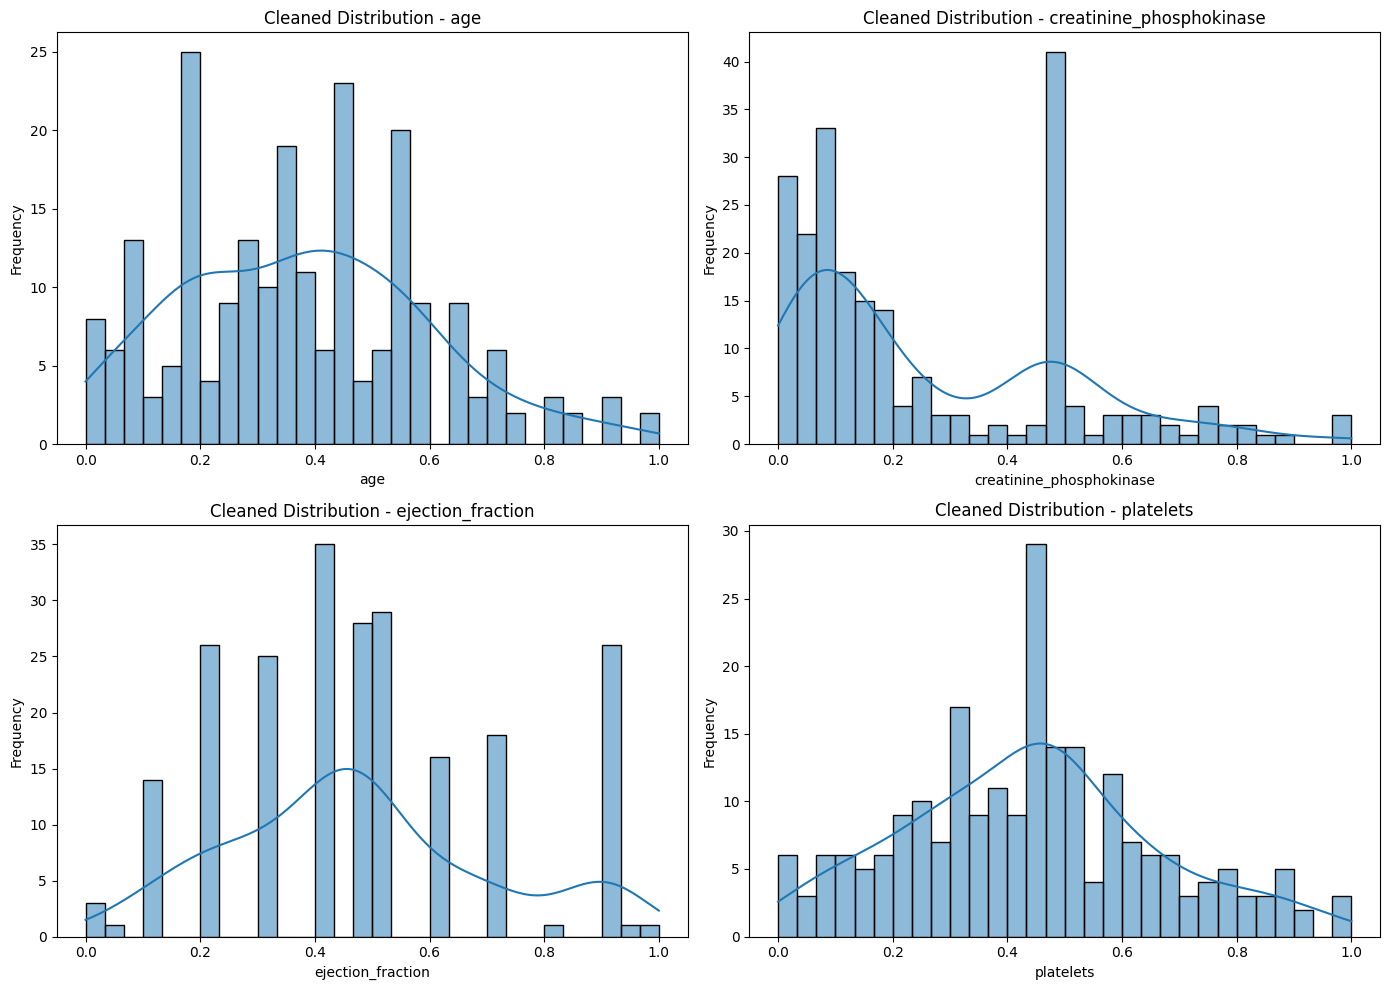

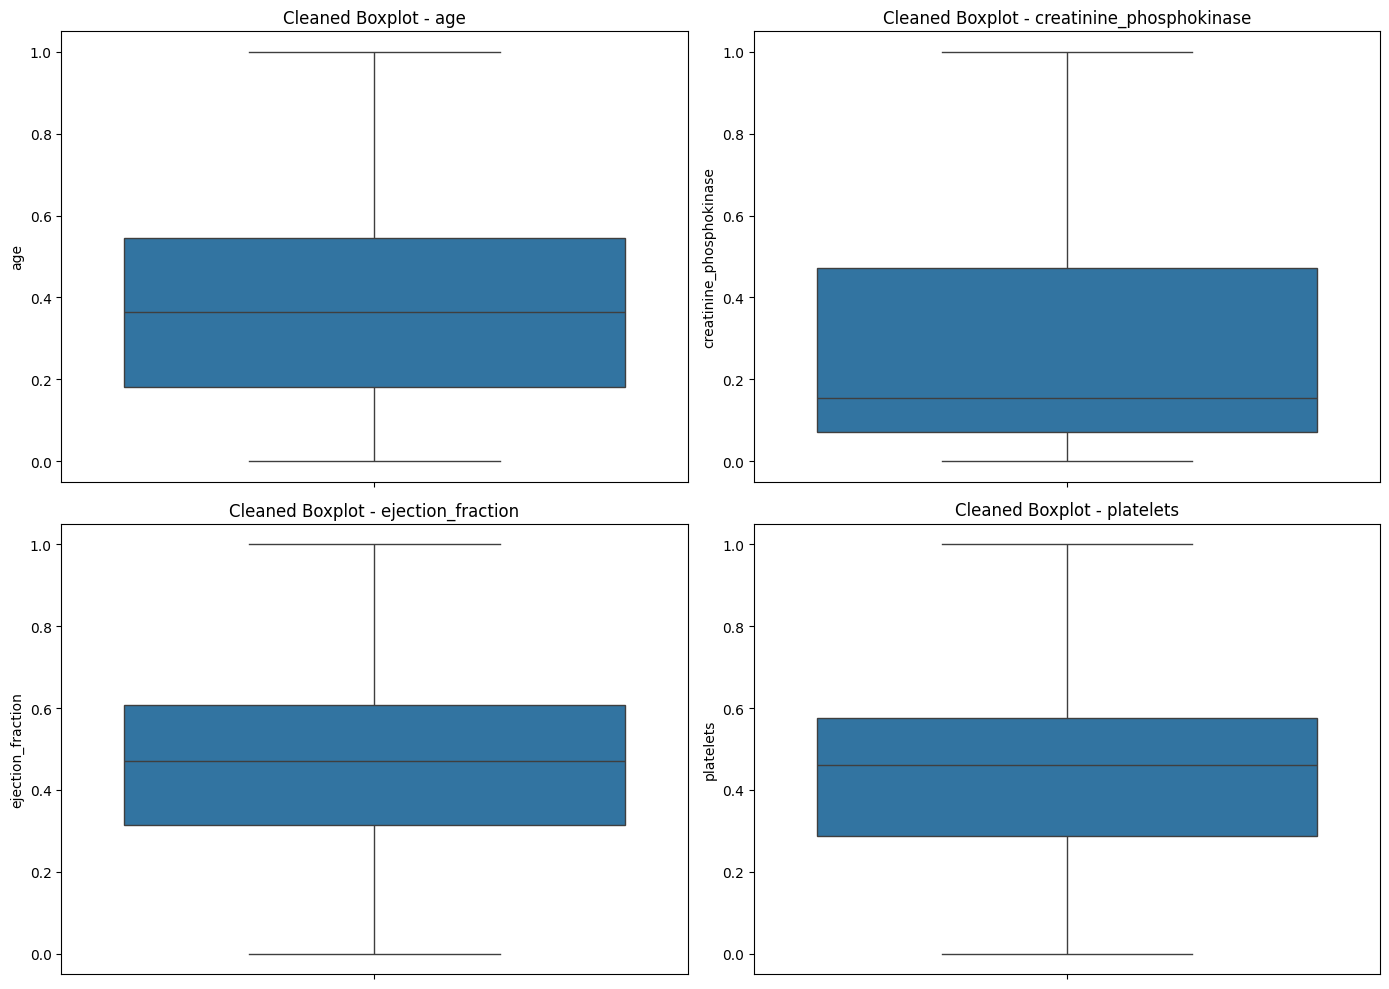


MISSING VALUES AFTER CLEANING
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values after cleaning: 0

DATA TYPES AFTER CLEANING
age                         float64
anaemia                       int64
creatinine_phosphokinase    float64
diabetes                      int64
ejection_fraction           float64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                float64
sex                           int64
smoking            

In [1]:
# ============================================================
# CSET343 - AI IN HEALTHCARE
# LAB ASSIGNMENT - 2
# DATA CLEANING AND ENRICHMENT
# Heart Failure Clinical Records Dataset
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 2. DOWNLOAD / LOAD DATASET
# ------------------------------------------------------------

# Dataset:
# https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)


# ------------------------------------------------------------
# 3. DISPLAY FIRST 5 ROWS
# ------------------------------------------------------------

print("\nFIRST 5 ROWS")
print("=" * 70)

print(df.head())


# ------------------------------------------------------------
# 4. DATASET SHAPE
# ------------------------------------------------------------

print("\nDATASET SHAPE")
print("=" * 70)

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])


# ------------------------------------------------------------
# 5. DATA TYPES
# ------------------------------------------------------------

print("\nDATA TYPES")
print("=" * 70)

print(df.dtypes)


# ------------------------------------------------------------
# 6. MISSING VALUES
# ------------------------------------------------------------

print("\nMISSING VALUES BEFORE CLEANING")
print("=" * 70)

print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())


# ------------------------------------------------------------
# 7. DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print("=" * 70)

df.info()


# ------------------------------------------------------------
# 8. SUMMARY STATISTICS BEFORE CLEANING
# ------------------------------------------------------------

print("\nSUMMARY STATISTICS BEFORE CLEANING")
print("=" * 70)

print(df.describe())


# ------------------------------------------------------------
# 9. MEAN, MEDIAN, STANDARD DEVIATION
# ------------------------------------------------------------

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("\nMEAN BEFORE CLEANING")
print("=" * 70)

print(df[numerical_columns].mean())


print("\nMEDIAN BEFORE CLEANING")
print("=" * 70)

print(df[numerical_columns].median())


print("\nSTANDARD DEVIATION BEFORE CLEANING")
print("=" * 70)

print(df[numerical_columns].std())


# ------------------------------------------------------------
# 10. VISUALIZE MISSING VALUES
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Rows")

plt.show()


# ------------------------------------------------------------
# 11. CHECK DUPLICATES
# ------------------------------------------------------------

print("\nDUPLICATE ROWS")
print("=" * 70)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


# ------------------------------------------------------------
# 12. PLOT DISTRIBUTIONS
# ------------------------------------------------------------

# Numerical features mentioned in assignment
features_to_plot = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

plt.figure(figsize=(14, 10))

for i, column in enumerate(features_to_plot, 1):

    plt.subplot(2, 2, i)

    sns.histplot(
        df[column],
        kde=True,
        bins=30
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. BOX PLOTS BEFORE CLEANING
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

for i, column in enumerate(features_to_plot, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        y=df[column]
    )

    plt.title("Boxplot of " + column)
    plt.ylabel(column)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. CHECK INVALID VALUES
# Example: negative age
# ------------------------------------------------------------

print("\nCHECKING INVALID VALUES")
print("=" * 70)

print("Negative age values:",
      (df["age"] < 0).sum())

print("Negative ejection fraction values:",
      (df["ejection_fraction"] < 0).sum())

print("Negative serum creatinine values:",
      (df["serum_creatinine"] < 0).sum())

print("Negative platelets values:",
      (df["platelets"] < 0).sum())


# ------------------------------------------------------------
# 15. CORRECT INVALID ENTRIES
# ------------------------------------------------------------

# Replace impossible negative values with NaN

df.loc[df["age"] < 0, "age"] = np.nan

df.loc[
    df["ejection_fraction"] < 0,
    "ejection_fraction"
] = np.nan

df.loc[
    df["serum_creatinine"] < 0,
    "serum_creatinine"
] = np.nan

df.loc[
    df["platelets"] < 0,
    "platelets"
] = np.nan


# ------------------------------------------------------------
# 16. MISSING VALUE IMPUTATION
# Numerical features -> Median
# ------------------------------------------------------------

numerical_columns = df.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].median()
        )


# ------------------------------------------------------------
# 17. CATEGORICAL MISSING VALUE IMPUTATION
# Mode
# ------------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].mode()[0]
        )


# ------------------------------------------------------------
# 18. REMOVE OUTLIERS USING IQR
# ------------------------------------------------------------

print("\nOUTLIER REMOVAL")
print("=" * 70)

# Columns where outlier removal makes sense
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

before_outlier_removal = df.shape[0]

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

after_outlier_removal = df.shape[0]

print("Rows before outlier removal:",
      before_outlier_removal)

print("Rows after outlier removal:",
      after_outlier_removal)

print("Rows removed:",
      before_outlier_removal - after_outlier_removal)


# ------------------------------------------------------------
# 19. AGE GROUP FEATURE ENGINEERING
# <40, 40-60, >60
# ------------------------------------------------------------

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=[
        "<40",
        "40-60",
        ">60"
    ],
    right=False
)

print("\nAGE GROUP DISTRIBUTION")
print("=" * 70)

print(df["age_group"].value_counts())


# ------------------------------------------------------------
# 20. CREATE RISK SCORE
# Normalized product of ejection_fraction
# and serum_creatinine
# ------------------------------------------------------------

df["ef_norm"] = (
    (df["ejection_fraction"] -
     df["ejection_fraction"].min())
    /
    (
        df["ejection_fraction"].max() -
        df["ejection_fraction"].min()
    )
)

df["creatinine_norm"] = (
    (df["serum_creatinine"] -
     df["serum_creatinine"].min())
    /
    (
        df["serum_creatinine"].max() -
        df["serum_creatinine"].min()
    )
)

# Product-based risk score

df["risk_score"] = (
    df["ef_norm"] *
    df["creatinine_norm"]
)

print("\nRISK SCORE")
print("=" * 70)

print(
    df[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head()
)


# ------------------------------------------------------------
# 21. REMOVE TEMPORARY NORMALIZATION COLUMNS
# ------------------------------------------------------------

df.drop(
    columns=[
        "ef_norm",
        "creatinine_norm"
    ],
    inplace=True
)


# ------------------------------------------------------------
# 22. ENCODE CATEGORICAL VARIABLES
# age_group -> One Hot Encoding
# ------------------------------------------------------------

df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=False,
    dtype=int
)


# ------------------------------------------------------------
# 23. CHECK DATA AFTER ENCODING
# ------------------------------------------------------------

print("\nDATA AFTER ENCODING")
print("=" * 70)

print(df.head())

print("\nNew columns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 24. NORMALIZE NUMERICAL FEATURES USING MINMAXSCALER
# Scale values between 0 and 1
# ------------------------------------------------------------

scaler = MinMaxScaler()

# Numerical columns
columns_to_scale = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "risk_score"
]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)


# ------------------------------------------------------------
# 25. SUMMARY STATISTICS AFTER CLEANING
# ------------------------------------------------------------

print("\nSUMMARY STATISTICS AFTER CLEANING")
print("=" * 70)

print(df.describe())


# ------------------------------------------------------------
# 26. MEAN AFTER CLEANING
# ------------------------------------------------------------

print("\nMEAN AFTER CLEANING")
print("=" * 70)

print(
    df[columns_to_scale].mean()
)


# ------------------------------------------------------------
# 27. MEDIAN AFTER CLEANING
# ------------------------------------------------------------

print("\nMEDIAN AFTER CLEANING")
print("=" * 70)

print(
    df[columns_to_scale].median()
)


# ------------------------------------------------------------
# 28. STANDARD DEVIATION AFTER CLEANING
# ------------------------------------------------------------

print("\nSTANDARD DEVIATION AFTER CLEANING")
print("=" * 70)

print(
    df[columns_to_scale].std()
)


# ------------------------------------------------------------
# 29. VALIDATE CLEANED DATA
# HISTOGRAMS
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

for i, column in enumerate(columns_to_scale[:4], 1):

    plt.subplot(2, 2, i)

    sns.histplot(
        df[column],
        kde=True,
        bins=30
    )

    plt.title(
        "Cleaned Distribution - " + column
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 30. CLEANED BOX PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

for i, column in enumerate(columns_to_scale[:4], 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        y=df[column]
    )

    plt.title(
        "Cleaned Boxplot - " + column
    )

    plt.ylabel(column)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 31. CHECK MISSING VALUES AFTER CLEANING
# ------------------------------------------------------------

print("\nMISSING VALUES AFTER CLEANING")
print("=" * 70)

missing_after = df.isnull().sum()

print(missing_after)

print(
    "\nTotal missing values after cleaning:",
    missing_after.sum()
)


# ------------------------------------------------------------
# 32. CHECK DATA TYPES AFTER CLEANING
# ------------------------------------------------------------

print("\nDATA TYPES AFTER CLEANING")
print("=" * 70)

print(df.dtypes)


# ------------------------------------------------------------
# 33. FINAL DATASET INFORMATION
# ------------------------------------------------------------

print("\nFINAL DATASET INFORMATION")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


# ------------------------------------------------------------
# 34. DISPLAY FINAL DATASET
# ------------------------------------------------------------

print("\nFINAL CLEANED DATASET")
print("=" * 70)

print(df.head(10))


# ------------------------------------------------------------
# 35. SAVE CLEANED DATASET
# ------------------------------------------------------------

output_file = "heart_failure_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned dataset saved as:",
      output_file)


# ------------------------------------------------------------
# 36. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print("Missing values:",
      df.isnull().sum().sum())

print("Duplicate rows:",
      df.duplicated().sum())

print("Minimum normalized value:",
      df[columns_to_scale].min().min())

print("Maximum normalized value:",
      df[columns_to_scale].max().max())

print("\nAssignment completed successfully.")